## 1. Import Libraries

This project uses Python for data processing, feature engineering, and clustering analysis. Key libraries include pandas for data manipulation, numpy for numerical operations, and matplotlib for visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Data

The analysis uses the Brazilian Olist e-commerce dataset, which includes multiple tables such as customers, orders, order items, and payments.

In [6]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

## 3. Data Preview

This step provides a quick overview of the datasets to understand their structure and key variables.

In [9]:
display(customers.head())
display(orders.head())
display(order_items.head())
display(payments.head())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)


The dataset contains multiple tables with different granularities, including customer-level, order-level, and transaction-level data. These tables will be merged to construct customer-level behavioral features.

## 4. Data Cleaning

The `order_purchase_timestamp` variable is converted to datetime format so that time-based features can be calculated later.  
Only delivered orders are kept, since completed purchases better reflect actual customer spending behavior.

In [15]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# Keep only delivered orders
valid_orders = orders[orders["order_status"] == "delivered"].copy()

print(valid_orders.shape)
print(valid_orders["order_status"].value_counts())

(96478, 8)
order_status
delivered    96478
Name: count, dtype: int64


## 5. Order-Level Aggregation

Order-level summaries are created from the order items and payment tables.  
These summaries help capture order value, item quantity, and payment behavior before building customer-level features.

In [18]:
order_summary = order_items.groupby("order_id").agg(
    order_value=("price", "sum"),
    total_freight=("freight_value", "sum"),
    item_count=("order_item_id", "count")
).reset_index()

payment_summary = payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "mean")
).reset_index()

display(order_summary.head())
display(payment_summary.head())

,order_id,order_value,total_freight,item_count
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


,order_id,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2.0
1,00018f77f2f0320c557190d7a144bdd3,259.83,3.0
2,000229ec398224ef6ca0657da4fc703e,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,25.78,2.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3.0


## 6. Merge Tables

The filtered orders table is merged with order-level summaries and customer identifiers.  
This creates a transaction dataset that can later be aggregated to the customer level.

In [21]:
orders_merged = valid_orders.merge(order_summary, on="order_id", how="left")
orders_merged = orders_merged.merge(payment_summary, on="order_id", how="left")
orders_merged = orders_merged.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

print(orders_merged.shape)
display(orders_merged.head())

(96478, 14)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value,total_freight,item_count,payment_value,payment_installments,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,1,38.71,1.0,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,1,141.46,1.0,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,1,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,1,72.20,1.0,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,1,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6


## 7. Feature Engineering

Customer-level behavioral features are created from transaction data to summarize purchasing patterns and customer activity over time.

The selected features are designed to capture key dimensions of customer behavior, including frequency, monetary value, engagement, and customer lifetime. These dimensions are commonly used in customer segmentation because they provide a concise and interpretable summary of purchasing behavior, while avoiding overly granular or noisy transaction-level details.


In [24]:
customer_features = orders_merged.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spent=("payment_value", "sum"),
    avg_order_value=("payment_value", "mean"),
    avg_items_per_order=("item_count", "mean"),
    avg_payment_installments=("payment_installments", "mean"),
    first_purchase=("order_purchase_timestamp", "min"),
    last_purchase=("order_purchase_timestamp", "max")
).reset_index()

reference_date = customer_features["last_purchase"].max()

customer_features["recency_days"] = (
    reference_date - customer_features["last_purchase"]
).dt.days

customer_features["customer_lifetime_days"] = (
    customer_features["last_purchase"] - customer_features["first_purchase"]
).dt.days

customer_features_final = customer_features.drop(columns=["first_purchase", "last_purchase"])

display(customer_features_final.head())

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_items_per_order,avg_payment_installments,recency_days,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1.0,8.0,111,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,1.0,114,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1.0,8.0,536,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1.0,4.0,320,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1.0,6.0,287,0


## 8. Check Missing Values and Summary Statistics

Before modeling, missing values and summary statistics are examined to understand the distribution of the engineered features.

In [27]:
print(customer_features_final.isnull().sum())
display(customer_features_final.describe())

customer_unique_id          0
total_orders                0
total_spent                 0
avg_order_value             1
avg_items_per_order         0
avg_payment_installments    1
recency_days                0
customer_lifetime_days      0
dtype: int64


,total_orders,total_spent,avg_order_value,avg_items_per_order,avg_payment_installments,recency_days,customer_lifetime_days
count,93358.000000,93358.000000,93357.000000,93358.000000,93357.000000,93358.000000,93358.000000
mean,1.033420,165.197003,160.316648,1.139531,2.899764,236.941773,2.634032
std,0.209097,226.314012,219.572062,0.527075,2.675901,152.591453,24.955822
min,1.000000,0.000000,9.590000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,63.052500,62.370000,1.000000,1.000000,113.000000,0.000000
50%,1.000000,107.780000,105.630000,1.000000,2.000000,218.000000,0.000000
75%,1.000000,182.557500,176.650000,1.000000,4.000000,345.000000,0.000000
max,15.000000,13664.080000,13664.080000,21.000000,24.000000,713.000000,633.000000


In [29]:
orders_merged[orders_merged["payment_value"].isnull()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value,total_freight,item_count,payment_value,payment_installments,customer_unique_id
29811,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00,134.97,8.49,3,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23


In [31]:
customer_features_final = customer_features_final.dropna()

In [33]:
print(customer_features_final.isnull().sum())

customer_unique_id          0
total_orders                0
total_spent                 0
avg_order_value             0
avg_items_per_order         0
avg_payment_installments    0
recency_days                0
customer_lifetime_days      0
dtype: int64


## 9. Data Distribution and Skewness

The distribution of total spending is highly right-skewed, indicating that a small number of customers contribute disproportionately high values. To address this issue, log transformation is applied to reduce skewness and improve clustering performance.

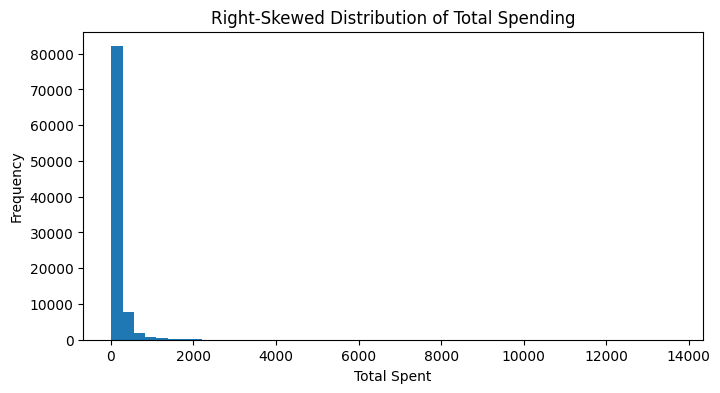

In [36]:
customer_features_final = customer_features_final.fillna(0)

plt.figure(figsize=(8, 4))
plt.hist(customer_features_final["total_spent"], bins=50)
plt.title("Right-Skewed Distribution of Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

## 10. Log Transformation

Several behavioral variables are log-transformed to reduce the effect of extreme values and make the data more suitable for clustering.

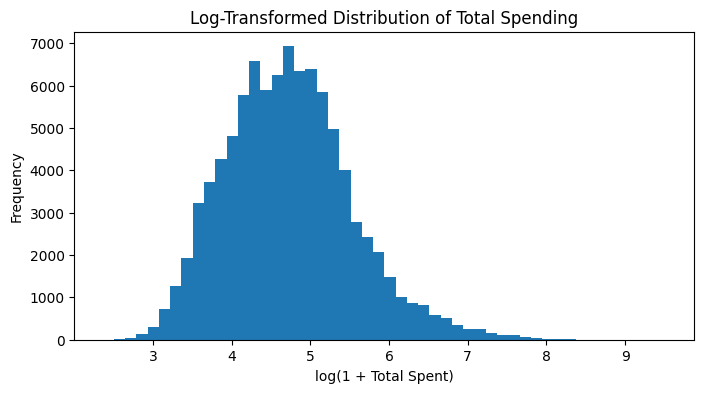

In [39]:
# Copy the cleaned customer-level feature table
feature_df = customer_features_final.copy()

# Apply log transformation to reduce skewness
skewed_cols = [
    "total_orders",
    "total_spent",
    "avg_order_value",
    "avg_items_per_order",
    "customer_lifetime_days",
    "recency_days"
]

for col in skewed_cols:
    feature_df[f"log_{col}"] = np.log1p(feature_df[col])

plt.figure(figsize=(8, 4))
plt.hist(feature_df["log_total_spent"], bins=50)
plt.title("Log-Transformed Distribution of Total Spending")
plt.xlabel("log(1 + Total Spent)")
plt.ylabel("Frequency")
plt.show()

## 11. Final Feature Preparation for Clustering

The final transformed features are selected as inputs for clustering analysis. 
These variables include the log-transformed behavioral metrics and payment-related features prepared for model training.

In [42]:
model_features = feature_df[[
    "log_total_orders",
    "log_total_spent",
    "log_avg_order_value",
    "log_avg_items_per_order",
    "avg_payment_installments",
    "log_recency_days",
    "log_customer_lifetime_days"
]]

X = model_features
display(model_features.describe())

,log_total_orders,log_total_spent,log_avg_order_value,log_avg_items_per_order,avg_payment_installments,log_recency_days,log_customer_lifetime_days
count,93357.000000,93357.000000,93357.000000,93357.000000,93357.000000,93357.000000,93357.000000
mean,0.706198,4.729149,4.707300,0.743320,2.899764,5.155286,0.089330
std,0.076683,0.808359,0.797295,0.164659,2.675901,0.950667,0.635291
min,0.693147,2.359910,2.359910,0.693147,0.000000,0.000000,0.000000
25%,0.693147,4.159820,4.148991,0.693147,1.000000,4.736198,0.000000
50%,0.693147,4.689327,4.669365,0.693147,2.000000,5.389072,0.000000
75%,0.693147,5.212542,5.179815,0.693147,4.000000,5.846439,0.000000
max,2.772589,9.522599,9.522599,3.091042,24.000000,6.543912,6.452049


## 12. Standardize Features

The selected features are standardized so that all variables are on comparable scales before PCA and clustering.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 13. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is applied to reduce feature redundancy and simplify the dataset before clustering. Since some behavioral variables may contain overlapping information, PCA helps transform the original features into a smaller set of uncorrelated components while preserving most of the overall variance. This improves clustering efficiency and reduces noise in the modeling process.

In [48]:
from sklearn.decomposition import PCA

# Run PCA on all components first
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

## 14. PCA Explained Variance

The scree plot and cumulative explained variance plot are used to determine how many principal components should be retained.

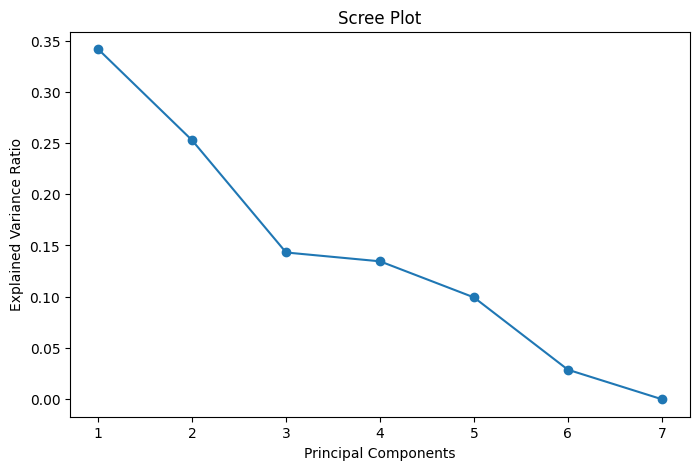

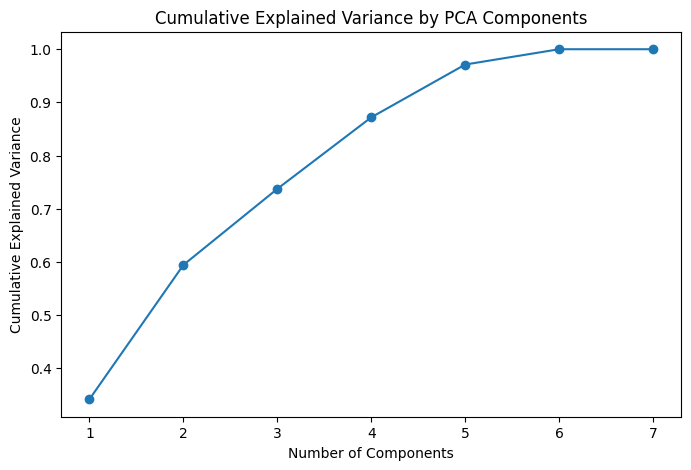

In [51]:
# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

# Cumulative explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.show()

In [53]:
# Select number of components to retain at least 85% variance
n_components = np.argmax(cumulative_variance >= 0.85) + 1
print("Selected number of components:", n_components)
print("Cumulative explained variance:", cumulative_variance[n_components - 1])

Selected number of components: 4
Cumulative explained variance: 0.871854737046321


The scree plot illustrates the variance explained by each principal component individually, helping identify diminishing returns in additional components. The cumulative explained variance plot shows the total variance retained as more components are included. Based on the cumulative explained variance threshold of 85%, four principal components were selected, retaining approximately 87.2% of the total variance.

## 15. Final PCA Dataset

Based on the cumulative explained variance, the final PCA-transformed dataset is created and used as input for clustering.

In [57]:
# Final PCA using the selected number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Convert PCA results to DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

display(pca_df.head())

,PC1,PC2,PC3,PC4
0,0.963045,-0.540174,-0.197308,-1.054128
1,-2.473656,0.486564,-0.375814,0.116216
2,0.220759,-0.447942,1.463351,-0.729372
3,-1.356268,0.071512,0.792147,-0.184154
4,1.167739,-0.624347,0.647650,-0.691254


In [61]:
# PCA Loadings (feature contributions to each principal component)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=model_features.columns
)

display(loadings)

,PC1,PC2,PC3,PC4
log_total_orders,0.196327,0.674589,0.064563,-0.000338
log_total_spent,0.614933,-0.105260,-0.030345,-0.060911
log_avg_order_value,0.592094,-0.214276,-0.041115,-0.061689
log_avg_items_per_order,0.228629,-0.056211,-0.114387,0.919902
avg_payment_installments,0.380927,-0.145608,0.133950,-0.351014
log_recency_days,-0.000038,-0.063526,0.980479,0.151229
log_customer_lifetime_days,0.188045,0.677893,0.029211,-0.013568


This PCA loading matrix shows how strongly each original customer behavior feature contributes to each principal component, helping interpret PC1 as spending behavior, PC2 as loyalty and repeat purchasing behavior, PC3 as recency, and PC4 as basket size behavior.

## 16. Application of K-Means Clustering

After dimensionality reduction, K-means clustering is selected to identify customer segments within the transformed feature space. K-means is chosen due to its simplicity, computational efficiency, and interpretability, making it well-suited for large-scale customer segmentation tasks. Additionally, K-means performs effectively on standardized and PCA-transformed data, where features are normalized and noise is reduced. Since K-means requires the number of clusters to be specified in advance, the elbow method is first applied to estimate an appropriate value for K.

## 17. Elbow Method

The elbow method is used as an initial reference for selecting the number of clusters.  
However, elbow results alone are not sufficient, so silhouette score and cluster balance are also considered.

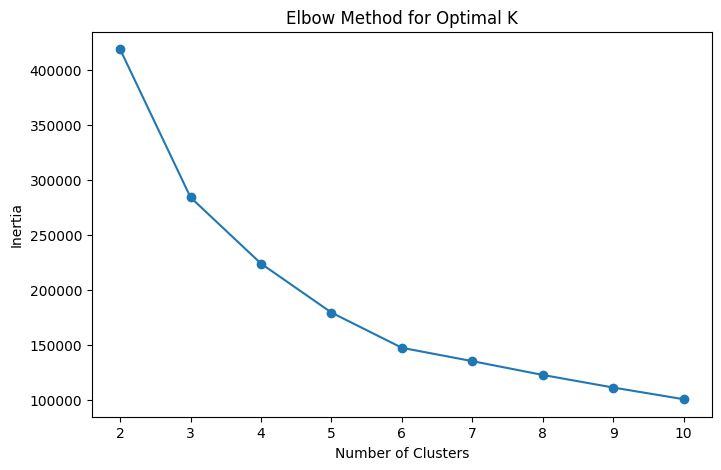

In [65]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

## 18. Silhouette Evaluation

To better evaluate clustering quality, silhouette scores are compared for K = 2, 3, and 4.  
In addition to separation quality, cluster balance is also examined because highly imbalanced clusters may have limited business usefulness.

In [70]:
from sklearn.metrics import silhouette_score

results = []

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_df)

    cluster_sizes = pd.Series(labels).value_counts(normalize=True).sort_index() * 100

    results.append({
        "k": k,
        "silhouette_score": silhouette_score(pca_df, labels),
        "largest_cluster_pct": cluster_sizes.max(),
        "smallest_cluster_pct": cluster_sizes.min()
    })

evaluation_df = pd.DataFrame(results)
display(evaluation_df)

,k,silhouette_score,largest_cluster_pct,smallest_cluster_pct
0,2,0.720127,97.842690,2.157310
1,3,0.357864,60.968112,2.149812
2,4,0.370702,55.811562,2.143385


The elbow method was first used as an initial diagnostic tool to identify a reasonable range for the number of clusters by examining the rate of inertia reduction. The elbow plot suggested that the improvement in inertia began to slow after approximately 3 to 5 clusters, indicating diminishing returns from adding additional clusters.
To further refine cluster selection, silhouette scores and cluster balance were evaluated for K = 2, 3, and 4. Although K = 2 produced the highest silhouette score, it resulted in a highly imbalanced cluster distribution, with over 97% of observations assigned to a single cluster, limiting its business usefulness. K = 3 was ultimately selected because it provided a reasonable balance between clustering quality, segment separation, and practical interpretability.


## 19. Final Customer Segmentation Results

K=3 was selected as the final solution because it provides a more interpretable and business-meaningful segmentation structure.

In [73]:
final_k = 3

final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(pca_df)

clustered_df = customer_features_final.copy()
clustered_df["cluster"] = final_labels

pca_plot_df = pca_df.copy()
pca_plot_df["cluster"] = final_labels

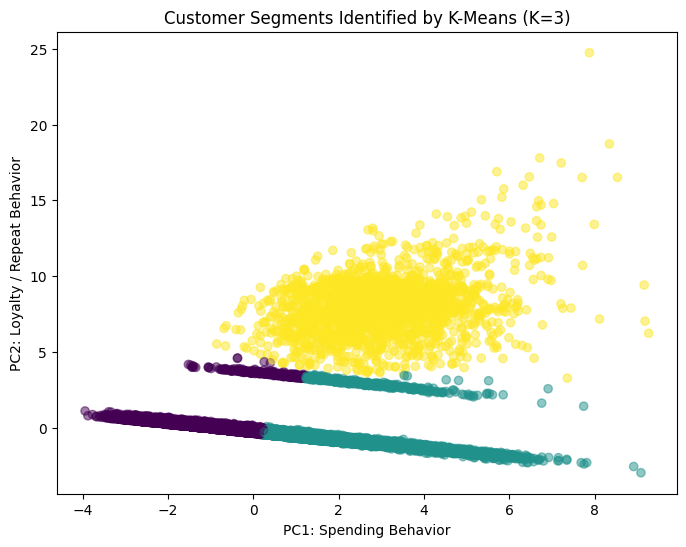

In [75]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_plot_df["PC1"],
    pca_plot_df["PC2"],
    c=pca_plot_df["cluster"],
    alpha=0.5
)

# Add business meaning to axis labels
plt.xlabel("PC1: Spending Behavior")
plt.ylabel("PC2: Loyalty / Repeat Behavior")

plt.title("Customer Segments Identified by K-Means (K=3)")

plt.show()

the purple cluster represents low-value one-time customers with low spending and short customer lifetime, the green cluster represents high-spending occasional customers who made larger purchases but showed limited repeat behavior, and the yellow cluster represents a small but highly valuable loyal customer segment with higher order frequency and longer customer lifetime, indicating stronger long-term engagement.

The final K-means clustering result is visualized in PCA space using the first two principal components. While some overlap exists between clusters, the plot shows that customers are reasonably differentiated into three segments, supporting the use of K = 3 for segmentation analysis.

In [79]:
profile_cols = [
    "total_orders",
    "total_spent",
    "avg_order_value",
    "avg_items_per_order",
    "avg_payment_installments",
    "recency_days",
    "customer_lifetime_days"
]

cluster_profile_mean = clustered_df.groupby("cluster")[profile_cols].mean()
cluster_size = clustered_df["cluster"].value_counts(normalize=True).sort_index() * 100

print("Cluster Size (%)")
display(cluster_size)

print("Cluster Profile - Mean")
display(cluster_profile_mean)

Cluster Size (%)


cluster
0    60.968112
1    36.882076
2     2.149812
Name: proportion, dtype: float64

Cluster Profile - Mean


,total_orders,total_spent,avg_order_value,avg_items_per_order,avg_payment_installments,recency_days,customer_lifetime_days
cluster,,,,,,,
0,1.006237,76.794557,76.387623,1.033654,1.810156,237.636424,0.000070
1,1.012750,302.410075,299.808600,1.310148,4.686129,238.414963,0.000174
2,2.158944,318.328600,147.404511,1.214146,3.153944,191.730443,122.520179


## Cluster Interpretation

The three clusters identified through K-means clustering represent distinct customer segments with different purchasing behaviors and levels of engagement.

Cluster 0 (60.9%) – Low-Engagement Customers:
This group consists of customers with minimal purchase activity and low spending. On average, these customers place around one order and spend approximately 77, suggesting that most are one-time or infrequent buyers.

Cluster 1 (36.9%) – Moderate-Value Customers:
This segment includes customers with higher spending levels, averaging around 300 per purchase. However, most place only one order, indicating that they tend to make higher-value but infrequent purchases. Their greater use of payment installments may suggest a willingness to spend on larger transactions.

Cluster 2 (2.1%) – High-Value Customers:
This small segment is characterized by higher order frequency and significantly longer customer lifetimes. With over two orders on average and customer lifetimes exceeding 120 days, these customers demonstrate stronger loyalty and repeat purchasing behavior.

These segments provide actionable insights for business strategies. For example, high-value customers can be prioritized for retention programs, moderate-value customers can be encouraged to purchase more frequently, and low-engagement customers may benefit from re-engagement campaigns.

## Discussion and Limitations

Although K=2 achieved the highest silhouette score, the resulting segmentation was highly imbalanced, with nearly 98% of customers grouped into a single cluster. This indicates that the model primarily separates typical customers from a small group of extreme-value customers, limiting its usefulness for detailed segmentation.

Additionally, customer behavior in this dataset is highly skewed, as most users place only one order and have very short customer lifetimes. While log transformation helps reduce the impact of extreme values, the overall lack of variability in customer activity may restrict the model’s ability to identify more nuanced segments.

Finally, the clustering model is based on a limited set of behavioral features and does not incorporate other potentially informative dimensions, such as product categories, customer preferences, or geographic patterns. As a result, the segmentation may not fully capture all aspects of customer behavior and could be further improved with richer data.